In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("diabetes.csv")
df = pd.DataFrame(data)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


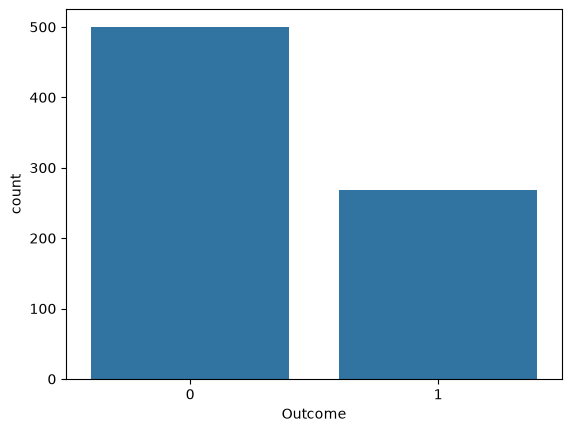

In [4]:
df["Outcome"].value_counts()
sns.countplot(x="Outcome",data = df)
plt.show()

In [5]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


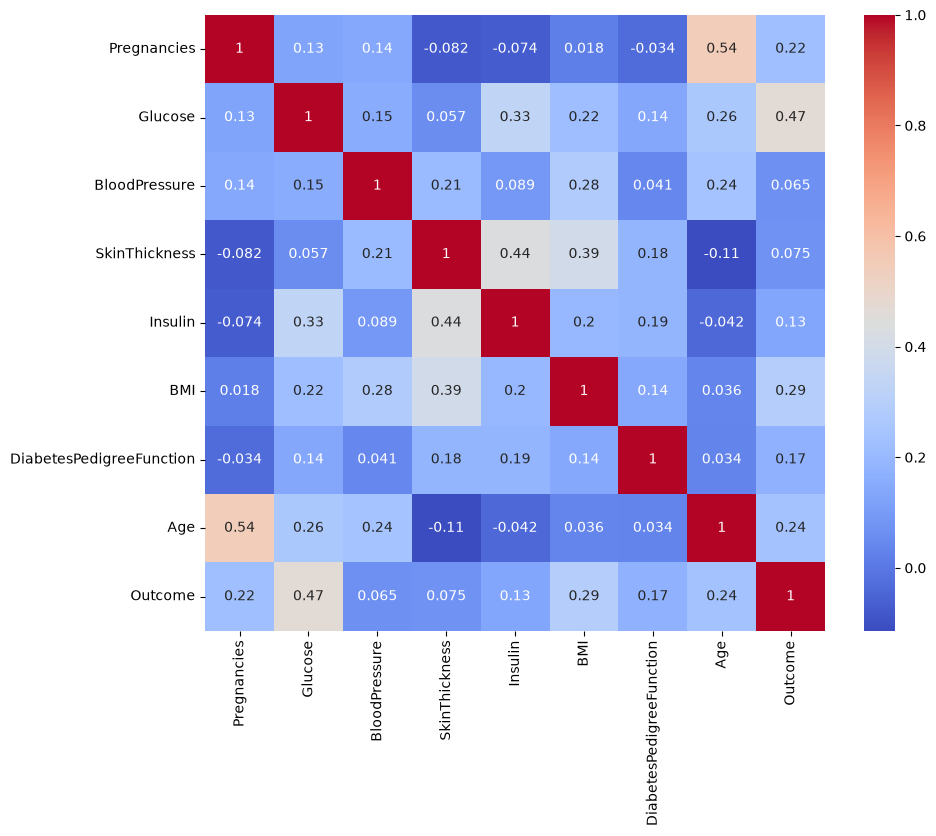

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [ ]:
# correlation
# ================
# Statistical method used to measure the relationship between two variables
# or columns(eg: age and glucose)
# it helps to understand how a change in one column affect another

# Types
# =======

# positive correlation
# ======================
# if value in one column increases the other column value also increases
# (Direct relationship >>>> value in between (0,1))

# Negative correlation
# ======================
# As one column value increase the other column value gets decreases
# (inverse relationship >>>> value in between (0,-1))

# Zero correlation
# ===================
# there is no relationship between other columns as if the value increase or decrease



# r = (Σ i = 1 to n(x_i - x) - (y_i - y)) / √([Σ i = 1 to n(x_i - x)^2 - ) √([Σ i = 1 to n(y_i - y)^2)



In [10]:
# separate features and target
X = df.drop("Outcome",axis = 1)
y = df["Outcome"]
X,y

(     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 0              6      148             72             35        0  33.6   
 1              1       85             66             29        0  26.6   
 2              8      183             64              0        0  23.3   
 3              1       89             66             23       94  28.1   
 4              0      137             40             35      168  43.1   
 ..           ...      ...            ...            ...      ...   ...   
 763           10      101             76             48      180  32.9   
 764            2      122             70             27        0  36.8   
 765            5      121             72             23      112  26.2   
 766            1      126             60              0        0  30.1   
 767            1       93             70             31        0  30.4   
 
      DiabetesPedigreeFunction  Age  
 0                       0.627   50  
 1                    

In [27]:
# train test split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42,stratify = y)

In [ ]:
# scaling >>> MIN Max scaling
# ===============================
# pregnancy
# 6
#              X - X_min
# X_scaled = ----------------
#             X_max - X_min

# Standard_scaling
# =====================
# X_scaled = (x - u) / s
# x = input from column
# u = mean of column
# s = standard deviation of the column
# X_scaled = scaled value




In [28]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(5)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0])

In [30]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test,y_pred))

0.70995670995671


In [ ]:
# diabetes(1) - positive
# no diabetes(0) - negative

# confusion matrix ->
# TP - true positive >> Actual result diabetes | model predict diabetes (correct prediction)
# TN - true negative >> Actual no diabetes | model predict no diabetes (correct)
# FP - false positive >> Actual no diabetes | model predict diabetes (wrong prediction)
# FN = false negative >> Actual diabetes | model predict no diabetes (wrong)

In [31]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test,y_pred))

# TP FP
# TN FN

[[121  29]
 [ 38  43]]


In [ ]:
# recall >> used to know how many of the actual positive cases were identified ny model

#              TP
# recall = ------------
#           TP + FN

# 

In [32]:
from sklearn.metrics import recall_score

print(recall_score(y_test,y_pred))

0.5308641975308642
